In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded from Colab secrets.")



Kaggle credentials loaded from Colab secrets.


In [ ]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:03<00:00, 113MB/s]



In [ ]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
folder_path = Path("/content/utkface_aligned_cropped/UTKFace")

print("Folder exists:", folder_path.exists())
print("Total files:", len(list(folder_path.glob("*.jpg"))))

Folder exists: True
Total files: 23708


In [ ]:
records = []

ETHNICITY_CLASSES = ["Asian", "Black", "White", "Indian", "Hispanic", "Other"]


for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")

        age = int(parts[0])
        gender = int(parts[1])
        ethnicity_idx = int(parts[2])
        ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

        if gender in [0, 1] and 1 <= age <= 116 and ethnicity in ETHNICITY_CLASSES:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender,
                "ethnicity": ethnicity
            })

    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()
ETHNICITY_CLASSES = ["Asian", "Black", "White", "Indian", "Hispanic", "Other"]

df["ethnicity"] = df["ethnicity"].apply(lambda x: ETHNICITY_CLASSES.index(x))



Dataset shape: (23705, 4)


Gender distribution:
gender
0    12391
1    11314
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64


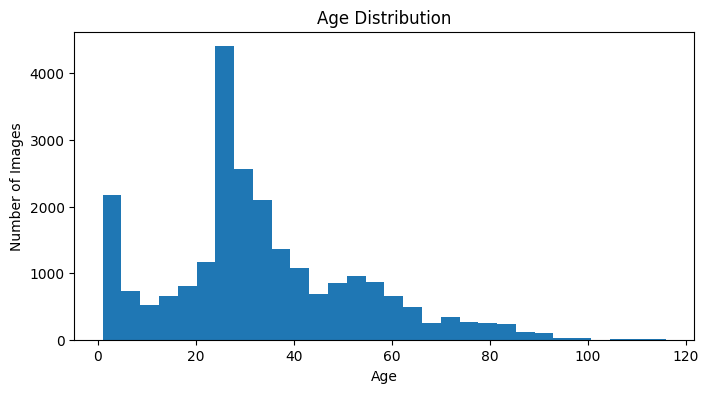

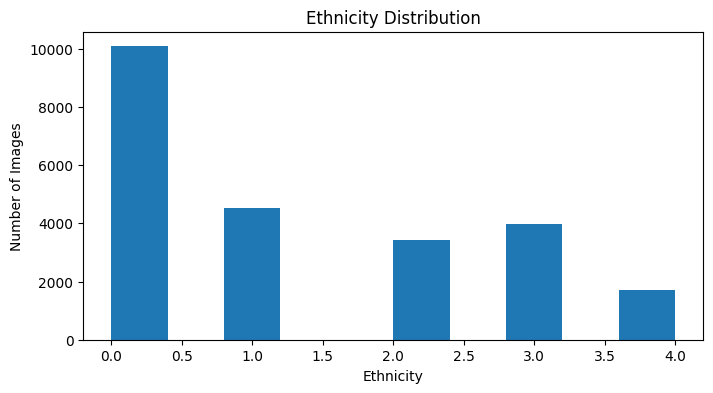

In [ ]:
print("Gender distribution:")
print(df["gender"].value_counts())

print("\nEthnicity distribution:")
print(df["ethnicity"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["ethnicity"])
plt.title("Ethnicity Distribution")
plt.xlabel("Ethnicity")
plt.ylabel("Number of Images")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gender"]
)

print("Training samples:", train_df.shape)
print("Validation samples:", val_df.shape)


Training samples: (18964, 4)
Validation samples: (4741, 4)


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
def load_image_and_labels(image_path, age, gender, ethnicity):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32),
        "ethnicity": tf.cast(ethnicity, tf.float32)
    }

    return image, labels
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values
    ethnicities = dataframe["ethnicity"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, ages, genders, ethnicities)
    )

    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully.")


TensorFlow datasets created successfully.


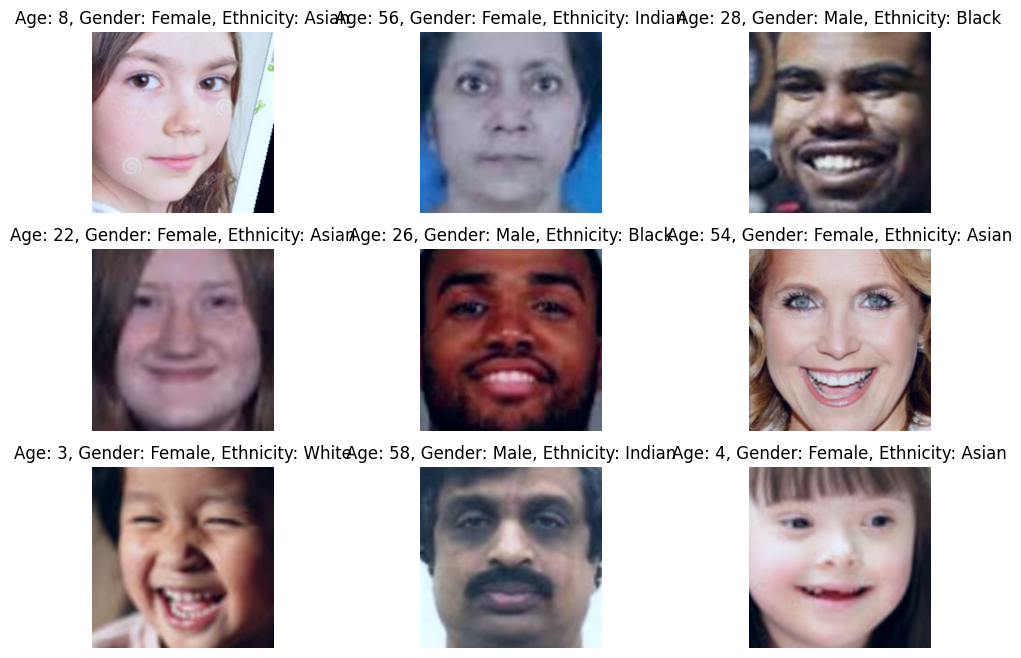

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(9):
        img = images[i].numpy()

        # Reverse ResNet preprocessing approximately for display
        img = img[..., ::-1]
        img = img + np.array([103.939, 116.779, 123.68])
        img = np.clip(img, 0, 255).astype("uint8")

        age = int(labels["age"][i].numpy())
        gender = int(labels["gender"][i].numpy())
        gender_name = "Female" if gender == 1 else "Male"


        ethnicity_idx = int(labels["ethnicity"][i].numpy())
        ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)


        plt.title(f"Age: {age}, Gender: {gender_name}, Ethnicity: {ethnicity}")

        plt.axis("off")

    plt.show()


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# -----------------------------
# OUTPUT HEADS
# -----------------------------

# Age → regression
age_output = layers.Dense(1, activation="linear", name="age")(x)

# Gender → binary classification
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)

# Ethnicity → multi-class classification (6 classes)
ethnicity_output = layers.Dense(
    6, activation="softmax", name="ethnicity"
)(x)

# -----------------------------
# FINAL MODEL
# -----------------------------
model = Model(
    inputs=inputs,
    outputs={
        "age": age_output,
        "gender": gender_output,
        "ethnicity": ethnicity_output
    }
)

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ethnicity (Dense)   │ (None, 6)         │      1,542 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,770,184 (94.49 MB)

 Trainable params: 1,182,472 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss={
        "age": "mse",
        "gender": "binary_crossentropy",
        "ethnicity": "sparse_categorical_crossentropy"
    },
    metrics={
        "age": "mae",
        "gender": "accuracy",
        "ethnicity": "accuracy"
    }
)


In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_age_gender_ethnicity_model.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)


In [39]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 97s 161ms/step - age_loss: 5.0369 - age_mae: 5.0371 - ethnicity_accuracy: 0.5770 - ethnicity_loss: 1.1491 - gender_accuracy: 0.8699 - gender_loss: 0.2972 - loss: 9.9702 - val_age_loss: 6.5176 - val_age_mae: 6.5212 - val_ethnicity_accuracy: 0.6224 - val_ethnicity_loss: 1.0402 - val_gender_accuracy: 0.8802 - val_gender_loss: 0.2589 - val_loss: 10.9382 - learning_rate: 1.0000e-05
Epoch 2/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 104s 173ms/step - age_loss: 4.8151 - age_mae: 4.8142 - ethnicity_accuracy: 0.5861 - ethnicity_loss: 1.1225 - gender_accuracy: 0.8772 - gender_loss: 0.2772 - loss: 9.5683 - val_age_loss: 6.4973 - val_age_mae: 6.5029 - val_ethnicity_accuracy: 0.6362 - val_ethnicity_loss: 1.0099 - val_gender_accuracy: 0.8888 - val_gender_loss: 0.2488 - val_loss: 10.7797 - learning_rate: 1.0000e-05
Epoch 3/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 98s 162ms/step - age_loss: 4.7425 - age_mae: 4.7423 - ethnicity_accuracy: 0.5991 - ethnicity_loss: 1.0926 - gender_accu

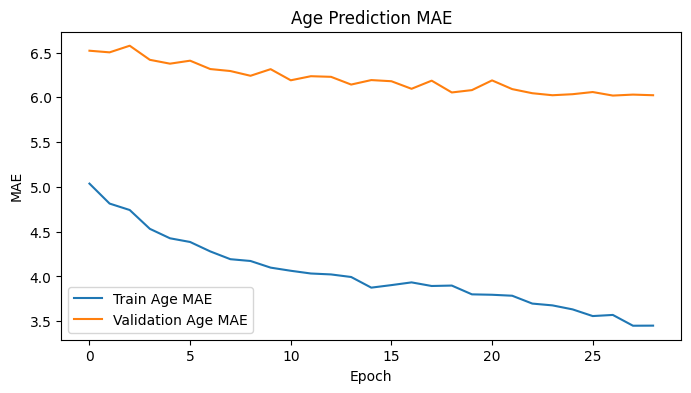

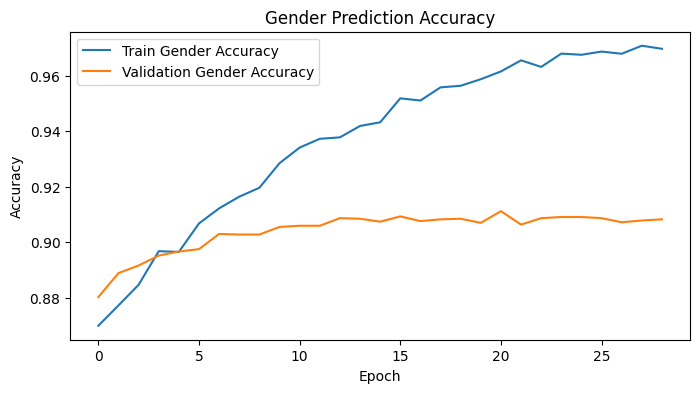

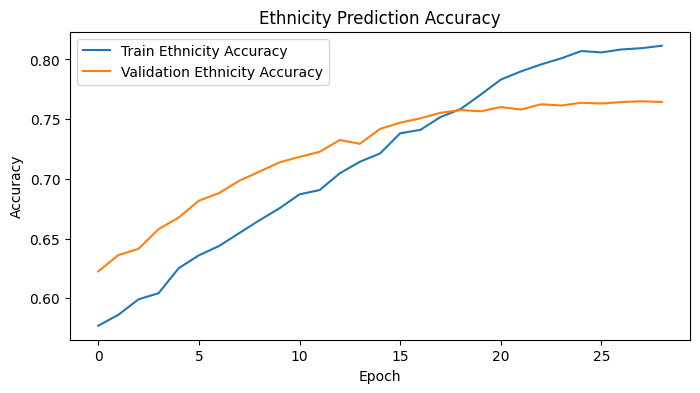

In [40]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["age_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["ethnicity_accuracy"], label="Train Ethnicity Accuracy")
plt.plot(history.history["val_ethnicity_accuracy"], label="Validation Ethnicity Accuracy")
plt.title("Ethnicity Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



 Fine-Tuning ResNet50 After training the custom head, we unfreeze the last few ResNet50 layers and train with a very small learning rate.

Fine-tuning can improve performance

In [41]:
base_model.trainable = True

# Freeze earlier layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "ethnicity": "sparse_categorical_crossentropy"
    },

    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "ethnicity": ["accuracy"]
    },

    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "ethnicity": 3.0
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 133s 185ms/step - age_loss: 3.6568 - age_mae: 3.6575 - ethnicity_accuracy: 0.8019 - ethnicity_loss: 0.5682 - gender_accuracy: 0.9666 - gender_loss: 0.0870 - loss: 5.7976 - val_age_loss: 6.0943 - val_age_mae: 6.1005 - val_ethnicity_accuracy: 0.7667 - val_ethnicity_loss: 0.6976 - val_gender_accuracy: 0.9118 - val_gender_loss: 0.2539 - val_loss: 9.4653 - learning_rate: 1.0000e-05
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 96s 159ms/step - age_loss: 3.7482 - age_mae: 3.7483 - ethnicity_accuracy: 0.8079 - ethnicity_loss: 0.5510 - gender_accuracy: 0.9678 - gender_loss: 0.0865 - loss: 5.8344 - val_age_loss: 6.0359 - val_age_mae: 6.0485 - val_ethnicity_accuracy: 0.7686 - val_ethnicity_loss: 0.6923 - val_gender_accuracy: 0.9089 - val_gender_loss: 0.2571 - val_loss: 9.4144 - learning_rate: 1.0000e-05
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 96s 158ms/step - age_loss: 3.7292 - age_mae: 3.7288 - ethnicity_accuracy: 0.8162 - ethnicity_loss: 0.5236 - gender_accuracy:

In [42]:
#evaluate the modal
results = model.evaluate(val_ds)
print("Evaluation Results:", results)


149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - age_loss: 6.0943 - age_mae: 6.1005 - ethnicity_accuracy: 0.7667 - ethnicity_loss: 0.6976 - gender_accuracy: 0.9118 - gender_loss: 0.2539 - loss: 9.4653
Evaluation Results: [9.465276718139648, 6.09425687789917, 0.25392377376556396, 0.6975558996200562, 6.1004557609558105, 0.7667158842086792, 0.9118329286575317]


Predict Age and Gender on One Image Upload or give the path of any face image and run this function.

In [43]:
from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array

Saving free-photo-of-portrait-of-old-man-with-moustache.jpeg to free-photo-of-portrait-of-old-man-with-moustache (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


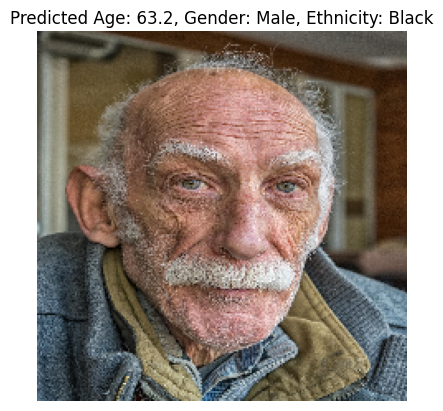

Predicted Age: 63.2
Predicted Gender: Male
Gender Probability (Female): 0.000
Predicted Ethnicity: Black


In [44]:
def predict_age_gender_ethnicity():
    # 1. Upload widget
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]

    # 2. Load image
    img = load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Predict
    prediction = model.predict(img_array)

    # 4. Handle all possible output formats
    if isinstance(prediction, dict):
        # Dict format: {"age": ..., "gender": ..., "ethnicity": ...}
        age = prediction["age"][0][0]
        gender_prob = prediction["gender"][0][0]

        # Ethnicity softmax → argmax
        ethnicity_idx = np.argmax(prediction["ethnicity"][0])
        ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

        gender = "Female" if gender_prob >= 0.5 else "Male"

    elif isinstance(prediction, list):
        # List format: [age, gender, ethnicity]
        age = prediction[0][0][0]
        gender_prob = prediction[1][0][0]

        # Ethnicity softmax → argmax
        ethnicity_idx = np.argmax(prediction[2][0])
        ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

        gender = "Female" if gender_prob >= 0.5 else "Male"

    else:
        # Single array output (rare)
        # Format: [age, gender_prob, e0, e1, e2, e3, e4, e5]
        age = prediction[0][0]
        gender_prob = prediction[0][1]

        #Ethnicity softmax → argmax
        ethnicity_idx = np.argmax(prediction[0][2:])
        ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

        gender = "Female" if gender_prob >= 0.5 else "Male"
    # 5. Show image + results
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Age: {age:.1f}, Gender: {gender}, Ethnicity: {ethnicity}")
    plt.show()

    # 6. Print results
    print(f"Predicted Age: {age:.1f}")
    print(f"Predicted Gender: {gender}")
    print(f"Gender Probability (Female): {gender_prob:.3f}")
    print(f"Predicted Ethnicity: {ethnicity}")
predict_age_gender_ethnicity()


In [45]:
model.save("best_resnet50_age_gender_ethnicity_model.keras")
print("Model saved successfully.")

Model saved successfully.


In [46]:
loaded_model = tf.keras.models.load_model("best_resnet50_age_gender_ethnicity_model.keras")
print("Model loaded successfully.")

Model loaded successfully.


In [47]:
import gradio as gr

def gradio_predict(image):
    # Convert to model input
    img = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)

    # Handle dict output
    if isinstance(prediction, dict):
        age = float(prediction["age"][0][0])
        gender_prob = float(prediction["gender"][0][0])
        ethnicity_idx = int(np.argmax(prediction["ethnicity"][0]))

    # Handle list output
    elif isinstance(prediction, list):
        age = float(prediction[0][0][0])
        gender_prob = float(prediction[1][0][0])
        ethnicity_idx = int(np.argmax(prediction[2][0]))

    # Handle single array output (rare)
    else:
        age = float(prediction[0][0])
        gender_prob = float(prediction[0][1])
        ethnicity_idx = int(np.argmax(prediction[0][2:]))

    gender = "Female" if gender_prob >= 0.5 else "Male"
    ethnicity = ETHNICITY_CLASSES[ethnicity_idx]

    # Return formatted text
    result = (
        f"Predicted Age: {age:.1f}\n"
        f"Predicted Gender: {gender} (Female Prob: {gender_prob:.3f})\n"
        f"Predicted Ethnicity: {ethnicity}"
    )

    return result


# Gradio Interface
interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=gr.Textbox(label="Prediction"),
    title="Age, Gender & Ethnicity Prediction",
    description="Upload a face image to predict age, gender, and ethnicity."
)

interface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c4e802a2dde902190.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
